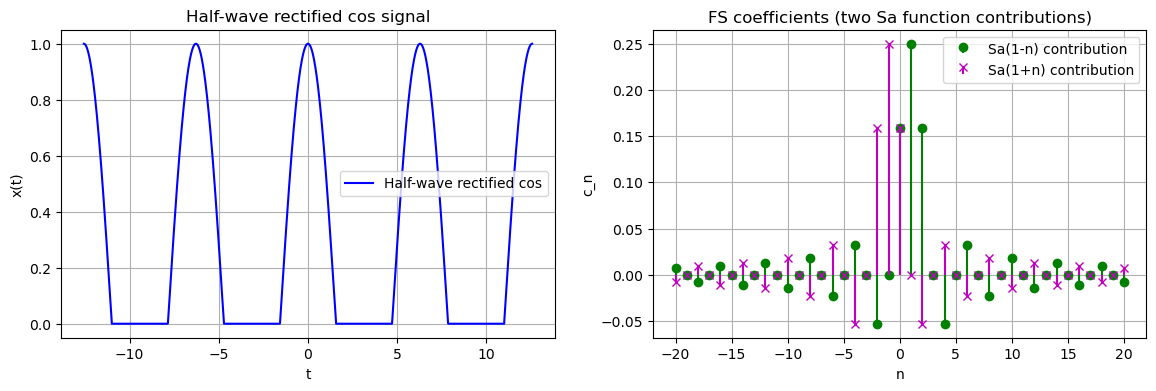

In [22]:
# Jupyter Notebook: Half-wave rectified cos - FS coefficients as Sa functions
import numpy as np
import matplotlib.pyplot as plt

# Signal parameters
A = 1
T0 = 2*np.pi
omega0 = 2*np.pi/T0
n_max = 20
t_plot = np.linspace(-2*T0, 2*T0, 2000)

def sa(x):
    """Normalized Sa function: sin(x)/x with Sa(0)=1"""
    return np.sinc(x/np.pi)  # numpy sinc is sin(pi*x)/(pi*x)

def fs_sa(n, A=1):
    """
    Analytical Fourier coefficients using two Sa functions
    Returns total, first Sa term, second Sa term
    """
    term1 = (A/4) * sa(np.pi/2 * (1 - n))
    term2 = (A/4) * sa(np.pi/2 * (1 + n))
    total = term1 + term2
    return total, term1, term2

# Compute FS coefficients
n = np.arange(-n_max, n_max+1)
total, term1, term2 = fs_sa(n, A)

# Half-wave rectified cosine
x_t = np.maximum(A*np.cos(omega0*t_plot), 0)

# Plotting
fig, axs = plt.subplots(1, 2, figsize=(14,4))

# Left: signal
axs[0].plot(t_plot, x_t, 'b', label='Half-wave rectified cos')
axs[0].set_title('Half-wave rectified cos signal')
axs[0].set_xlabel('t')
axs[0].set_ylabel('x(t)')
axs[0].grid(True)
axs[0].legend()

# Right: FS coefficients with transparency
axs[1].stem(n, term1, linefmt='g-', markerfmt='go', basefmt=" ", label='Sa(1-n) contribution')
axs[1].stem(n, term2, linefmt='m-', markerfmt='mx', basefmt=" ", label='Sa(1+n) contribution')
#axs[1].stem(n, total, linefmt='r-', markerfmt='ro', basefmt=" ", label='Total c_n')
axs[1].set_title('FS coefficients (two Sa function contributions)')
axs[1].set_xlabel('n')
axs[1].set_ylabel('c_n')
axs[1].grid(True)
axs[1].legend()

plt.show()